In [2]:
import json
import os
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, f1_score
from sklearn.feature_selection import VarianceThreshold


In [6]:
def plot_f1_vs_kpos(ax, metrics_df: pd.DataFrame):
    """
    One curve per (tag, classifier_type) showing F1 vs number of positives.
    Saves PNG to output_dir.
    """
    #fig, ax = plt.subplots(figsize=(10, 6))
    tags = metrics_df["tag"].unique()
    cmap = plt.cm.tab20(np.linspace(0, 1, len(tags)))

    for color, tag in zip(cmap, sorted(tags)):
        sub = metrics_df[metrics_df["tag"] == tag].sort_values("kpos")
        ax.plot(sub["kpos"], sub["f1"], marker="o", label=tag, color=color)

    ax.set_xlabel("Number of positive training examples", fontsize=12)
    ax.set_ylabel("F1 ", fontsize=12)
    #ax.set_title("Test F1 vs training positives – all configurations", fontsize=13)
    ax.legend( loc="upper left", fontsize=7) #bbox_to_anchor=(1.02, 1),
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    #path = output_dir / "f1_vs_kpos.png"
    #fig.savefig(path, dpi=150)
    #plt.close(fig)
    #print(f"[plot] saved → {path}")
    #plt.show()

In [4]:
res = pd.read_csv('/ceph/hpc/home/contardog/MALLORN/SupCon_logs/ELASTICC2_mallornlike/results/all_metrics.csv')
res

,tag,kpos,f1,precision_1,recall_1,support_1,f1_macro,cv_f1,best_C,best_penalty
0,bestmall_catboost,50,0.819401,0.846482,0.794,500.0,0.905103,0.731105,NaN,NaN
1,supconrun_selfsupsupcon_1-1_linearSVC,50,0.652314,0.706294,0.606,500.0,0.817689,0.923723,0.01,l1
2,supconrun_selfsupsupcon_1-1_catboost_CLS,50,0.645435,0.687783,0.608,500.0,0.813955,0.934679,NaN,NaN
3,supconrun_selfsupsupcon_1-1_temp007_linearSVC,50,0.526181,0.727915,0.412,500.0,0.753438,0.884675,0.01,l1
4,supconrun_selfsupsupcon_1-1_temp007_catboost_CLS,50,0.504698,0.767347,0.376,500.0,0.742767,0.901364,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
133,supconrun_selfsuponly_catboost_CLS,300,0.596273,0.618026,0.576,500.0,0.787892,0.729638,NaN,NaN
134,supconrun_selfsuponly_temp007_linearSVC,300,0.509248,0.368093,0.826,500.0,0.732968,0.659433,10.00,l2
135,supconrun_selfsuponly_temp007_catboost_CLS,300,0.530442,0.454936,0.636,500.0,0.750248,0.679988,NaN,NaN
136,supconrun_selfsuponly_temp007_nounsup_linearSVC,300,0.515924,0.378505,0.810,500.0,0.737343,0.625149,10.00,l2


/tmp/ipykernel_3680940/3754242636.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend( loc="upper left", fontsize=7) #bbox_to_anchor=(1.02, 1),


Text(0.5, 1.0, 'Without unsup with Temp 0.15')

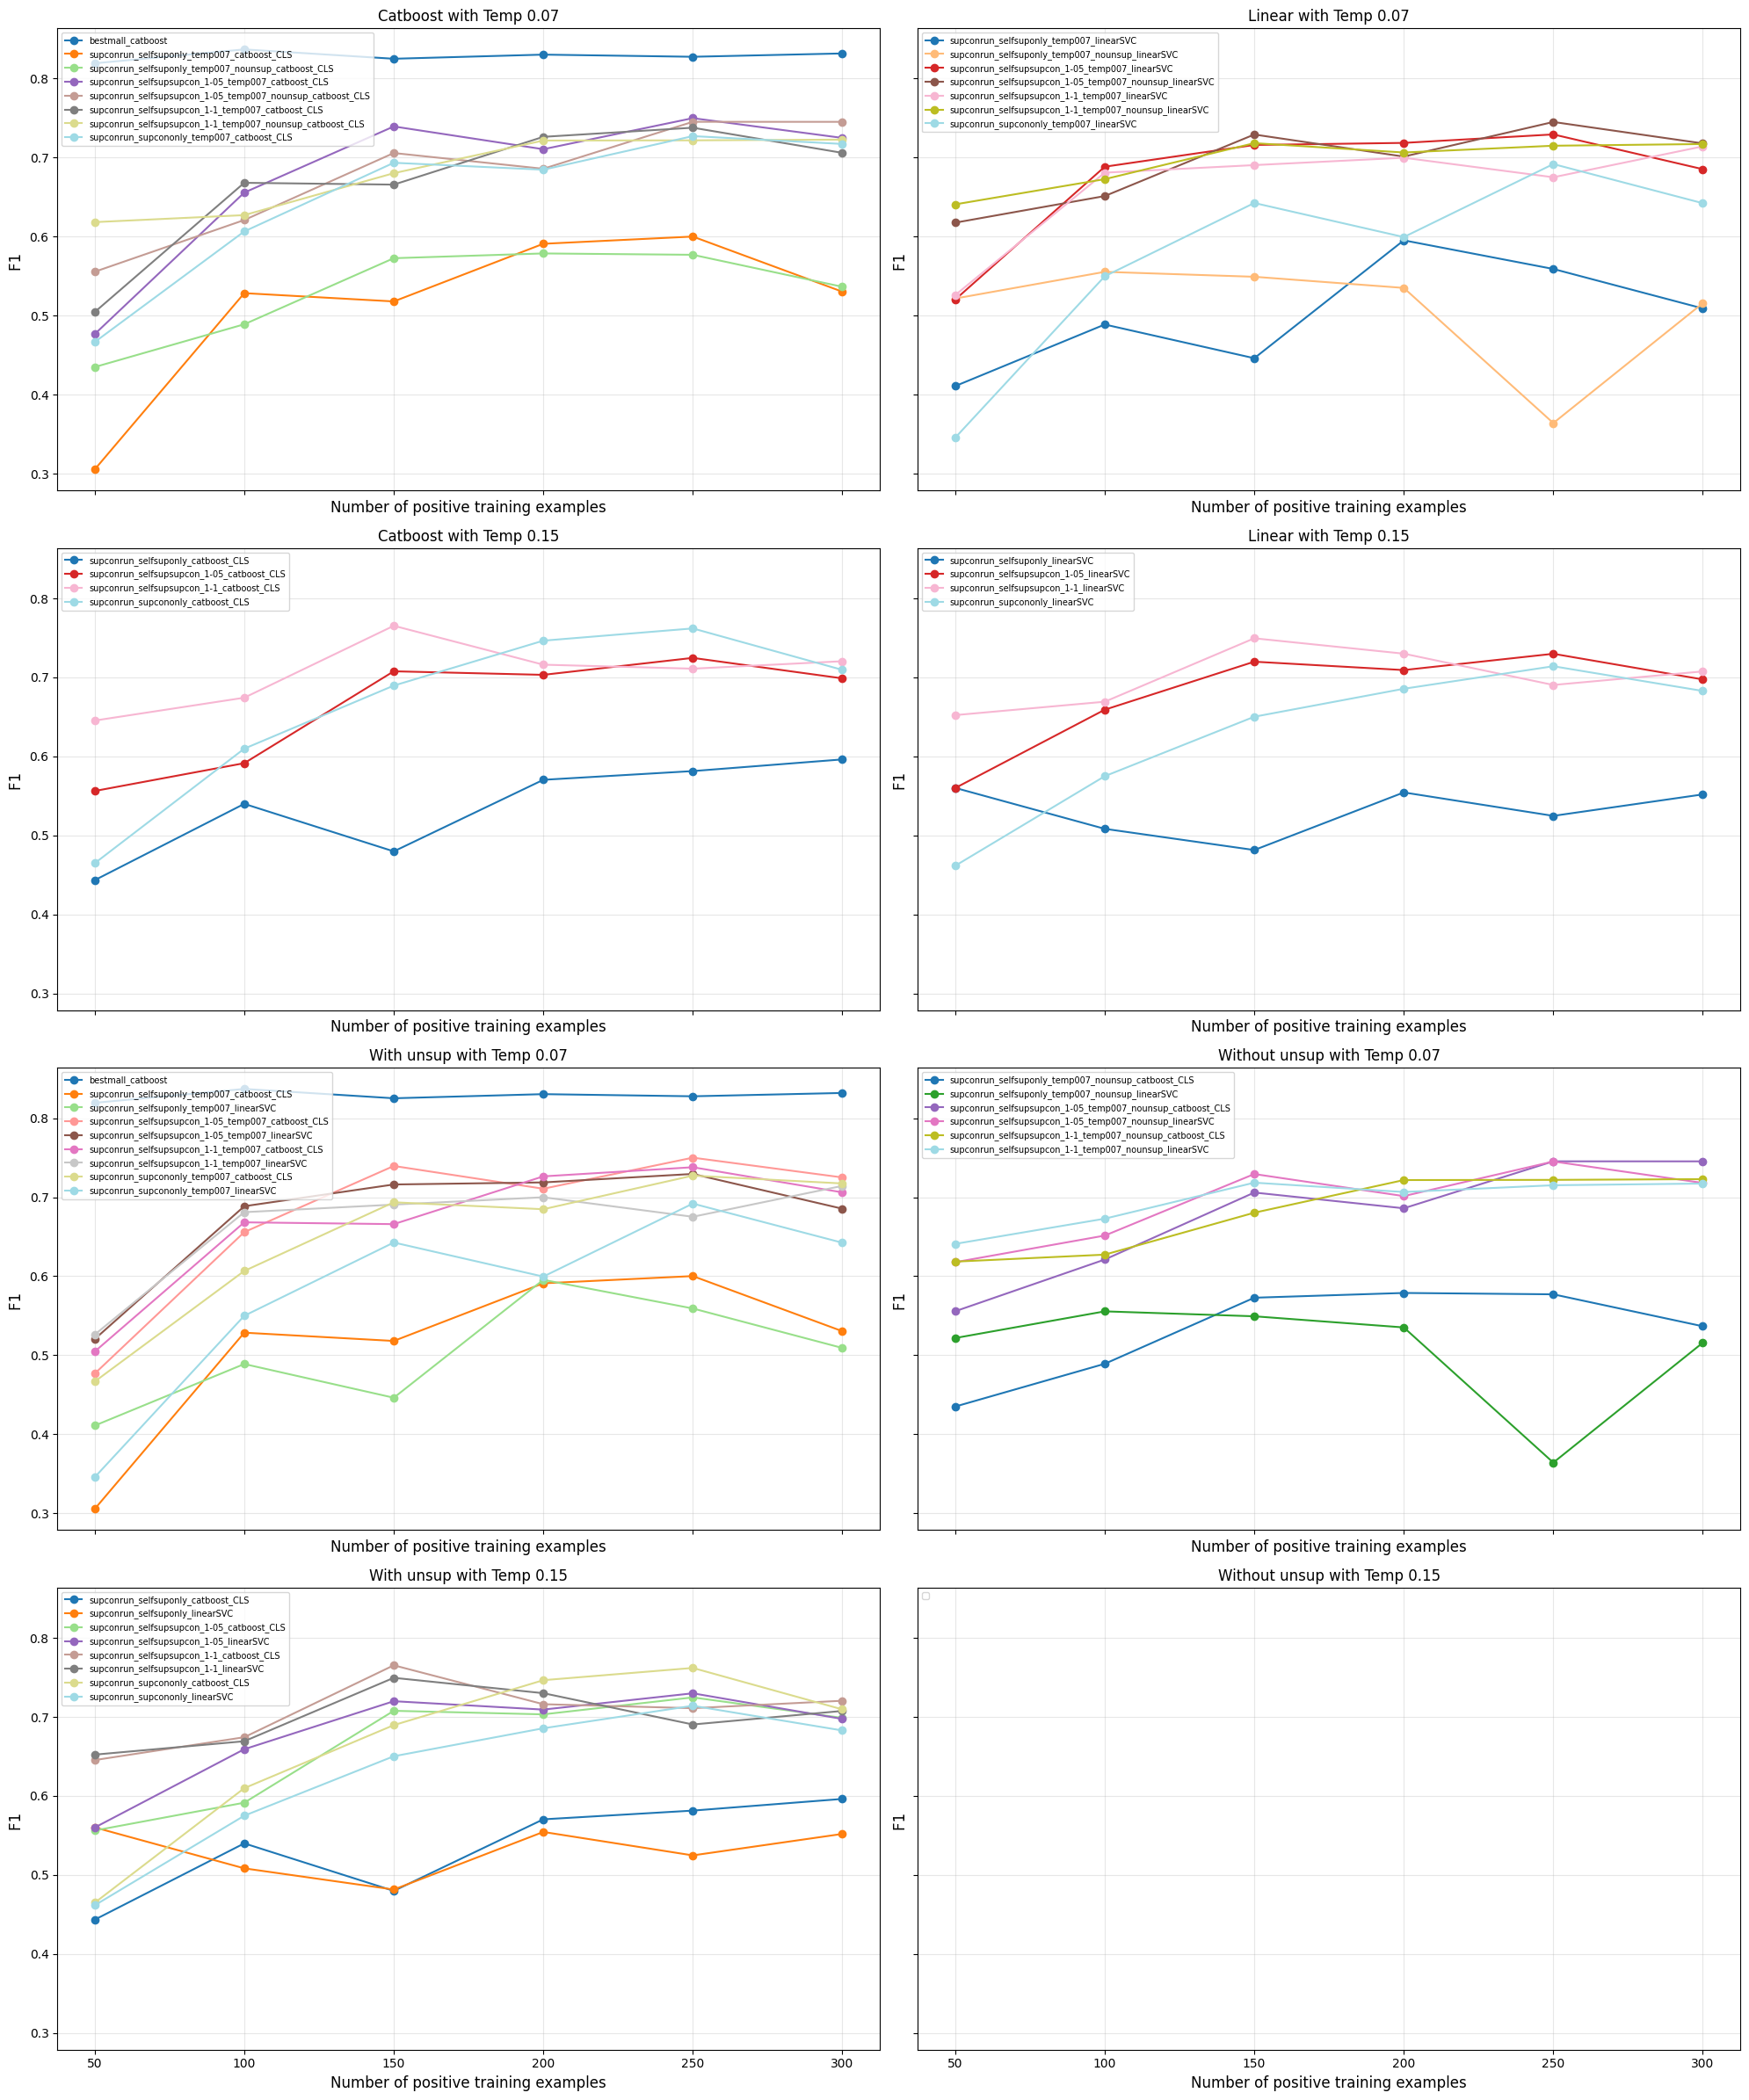

In [12]:


fig, axs = plt.subplots(4,2, figsize=(10*2,6*4), sharey=True, sharex=True)

mask_cat = np.array(['catboost' in tag for tag in res['tag']])
mask_temp = np.array([('007' in tag or 'bestmall' in tag) for tag in res['tag']])
mask_unsup = np.array(['nounsup' in tag for tag in res['tag']])

## catboost vs linear for temp 007
plot_f1_vs_kpos(axs[0,0], res[mask_cat & mask_temp])
axs[0,0].set_title('Catboost with Temp 0.07')
plot_f1_vs_kpos(axs[0,1], res[~mask_cat & mask_temp])
axs[0,1].set_title('Linear with Temp 0.07')

## catboost vs linear for temp 015
plot_f1_vs_kpos(axs[1,0], res[mask_cat & ~mask_temp])
axs[1,0].set_title('Catboost with Temp 0.15')
plot_f1_vs_kpos(axs[1,1], res[~mask_cat & ~mask_temp])
axs[1,1].set_title('Linear with Temp 0.15')

## with unsup vs without for temp 007
plot_f1_vs_kpos(axs[2,0], res[~mask_unsup & mask_temp])
axs[2,0].set_title('With unsup with Temp 0.07')
plot_f1_vs_kpos(axs[2,1], res[mask_unsup & mask_temp])
axs[2,1].set_title('Without unsup with Temp 0.07')

## with unsup vs without for temp 015

plot_f1_vs_kpos(axs[3,0], res[~mask_unsup & ~mask_temp])
axs[3,0].set_title('With unsup with Temp 0.15')
plot_f1_vs_kpos(axs[3,1], res[mask_unsup & ~mask_temp])
axs[3,1].set_title('Without unsup with Temp 0.15')